# Cereal Project : Joel Hurtado - 20250310

In [2]:
# import required (all) libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
# upload excel file
from google.colab import files
uploaded = files.upload()

Saving Dominos_Pizza_Data.xlsx to Dominos_Pizza_Data.xlsx


In [4]:
# read excel
df = pd.read_excel('Dominos_Pizza_Data.xlsx')
df

,Key,Date,mmdd,DayOfTheWeek,Distance,Timestamp,Tip,OrderAmount,TipPercent,Housing,GenderOfTipper,Cash_Credit_Tip,Web_Site,PersonWhoDelivered,Area,Satisfaction_Rate,Recom_Rate,month
0,712,42233,817,Monday,3.0,0.854167,4.13,12.87,32.090132,Hotel,Male,Cash,0,Sammie,Downtown,0.008093,0.01,Aug
1,339,42212,727,Monday,3.1,0.521528,3.36,15.44,21.761658,Business,Male,Cash,0,Thomas,South,0.008313,0.01,Jul
2,1164,42287,1010,Saturday,3.1,0.762500,0.00,15.71,0.000000,House,Female,Cash,0,Andria,West,0.008337,0.01,Oct
3,1189,42289,1012,Monday,2.5,0.756944,2.00,14.65,13.651877,House,Male,Cash,0,Thomas,South,0.008526,0.01,Oct
4,1085,42288,1011,Sunday,2.5,0.775000,5.22,16.78,31.108463,Apartment,Male,Cash,0,Andria,South,0.008688,0.01,Oct
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1296,1181,42239,823,Sunday,1.2,0.758333,4.00,16.07,24.891101,House,Male,Credit,0,Thomas,East,NaN,0.43,Aug
1297,465,42294,1017,Saturday,3.3,0.954861,3.92,16.08,24.378110,House,Male,Cash,0,Angel,West,NaN,0.48,Oct
1298,252,42217,801,Saturday,2.2,0.600000,3.00,17.03,17.615972,House,Female,Credit,0,Thomas,East,NaN,0.45,Aug
1299,261,42221,805,Wednesday,2.8,0.592361,3.00,18.37,16.330974,Business,Male,Credit,0,Thomas,South,NaN,0.46,Aug


In [ ]:
# Display a summary of the basic information

In [5]:
# df dimensions
df.shape

(1301, 18)

In [6]:
# df columns
df.columns

Index(['Key', 'Date', 'mmdd', 'DayOfTheWeek', 'Distance', 'Timestamp', 'Tip',
       'OrderAmount', 'TipPercent', 'Housing', 'GenderOfTipper',
       'Cash_Credit_Tip', 'Web_Site', 'PersonWhoDelivered', 'Area',
       'Satisfaction_Rate', 'Recom_Rate', 'month'],
      dtype='object')

In [7]:
# df information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1301 entries, 0 to 1300
Data columns (total 18 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Key                 1301 non-null   int64  
 1   Date                1301 non-null   int64  
 2   mmdd                1301 non-null   int64  
 3   DayOfTheWeek        1301 non-null   object 
 4   Distance            1290 non-null   float64
 5   Timestamp           1301 non-null   float64
 6   Tip                 1301 non-null   float64
 7   OrderAmount         1290 non-null   float64
 8   TipPercent          1301 non-null   float64
 9   Housing             1301 non-null   object 
 10  GenderOfTipper      1301 non-null   object 
 11  Cash_Credit_Tip     1301 non-null   object 
 12  Web_Site            1301 non-null   int64  
 13  PersonWhoDelivered  1301 non-null   object 
 14  Area                1301 non-null   object 
 15  Satisfaction_Rate   1294 non-null   float64
 16  Recom_

In [ ]:
# Clean data-frame (df)


In [8]:
# List of missing values by columns
df.isna().sum()

,0
Key,0
Date,0
mmdd,0
DayOfTheWeek,0
Distance,11
Timestamp,0
Tip,0
OrderAmount,11
TipPercent,0
Housing,0


In [9]:
# select the num columns
num_cols = df.select_dtypes(include=np.number).columns
#replace by the mean
for col in num_cols:
  df[col] = df[col].fillna(df[col].mean())

In [10]:
# clean the num cols
for col in num_cols:
  df[col] = df[col].fillna(df[col].mean())

In [11]:
df.isna().sum()

,0
Key,0
Date,0
mmdd,0
DayOfTheWeek,0
Distance,0
Timestamp,0
Tip,0
OrderAmount,0
TipPercent,0
Housing,0


In [12]:
# Person who delivered the maximum order amount
pwd = df[df["OrderAmount"] == df["OrderAmount"].max()][["PersonWhoDelivered", "OrderAmount"]]
pwd

,PersonWhoDelivered,OrderAmount
900,Angel,97.18


In [13]:
# Print the Total of "Order Amount" & total of "Distance" by "PersonWhoDelivered"
tab1 = df.groupby("PersonWhoDelivered").sum()[["OrderAmount", "Distance"]].reset_index()
tab1

,PersonWhoDelivered,OrderAmount,Distance
0,Andria,6103.263170,657.828372
1,Angel,7288.940170,776.860000
2,Sammie,6733.250000,705.517349
3,Thomas,8340.500283,830.854698


In [14]:
# Find the Average "Order Amount" by "month" and by "area"
tab2 = df.groupby(["month", "Area"])[["OrderAmount"]].mean().reset_index()
tab2

,month,Area,OrderAmount
0,Aug,Downtown,21.203729
1,Aug,East,21.633395
2,Aug,North,20.289922
3,Aug,South,22.542307
4,Aug,West,22.029123
5,Jul,Downtown,21.011765
6,Jul,East,22.898043
7,Jul,North,22.028913
8,Jul,South,20.039687
9,Jul,West,26.974762


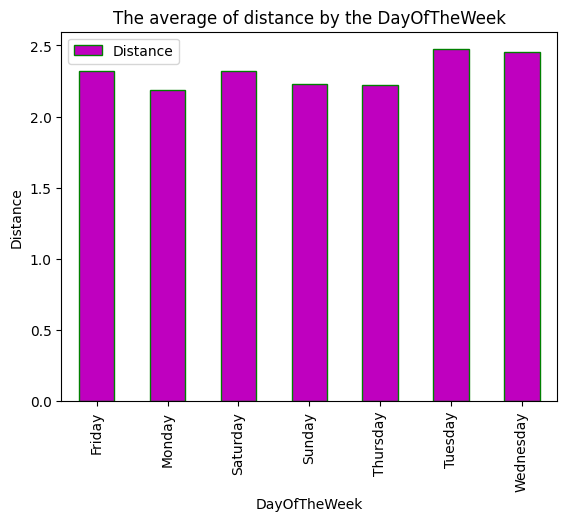

In [15]:
# The graph of average of "distance" of the "DayOfTheWeek"
# (X label name = "DayOfTheWeek" Y label name = "Average Distance")
import matplotlib.pyplot as plt
import seaborn as sns
graph1 = df.groupby("DayOfTheWeek")[["Distance"]].mean().reset_index()
graph1.plot(x="DayOfTheWeek", y="Distance", kind="bar", color = "m", edgecolor = "g")
plt.title("The average of distance by the DayOfTheWeek")
plt.xlabel("DayOfTheWeek")
plt.ylabel("Distance")
plt.show()

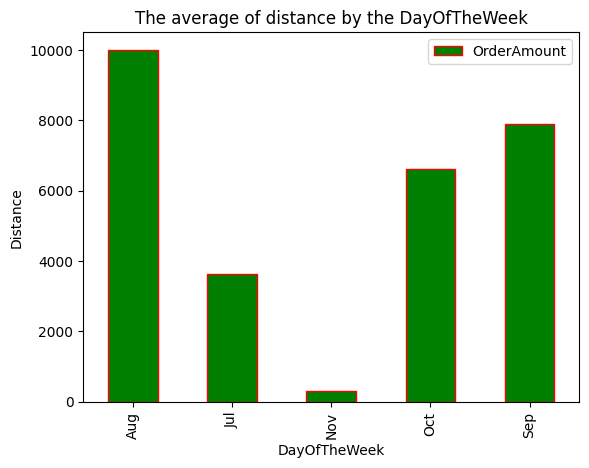

In [16]:
# The graph of total " OrderAmount" of the ‘month’
graph1 = df.groupby("month")[["OrderAmount"]].sum().reset_index()
graph1.plot(x="month", y="OrderAmount", kind="bar", color = "g", edgecolor = "r")
plt.title("The average of distance by the DayOfTheWeek")
plt.xlabel("DayOfTheWeek")
plt.ylabel("Distance")
plt.show()

In [23]:
# Select df august
aug_df = df[df["month"] == "Aug"]

# Create Perf_Score column
df_aug["Perf_Score"] = df_aug["Satisfaction_Rate"] / (1 - df_aug["Recom_Rate"])

# Displat the average of Perf_Score by person who delivered
tab_perf_score = df_aug.groupby("PersonWhoDelivered")[["Perf_Score"]].mean().reset_index()
tab_perf_score

/tmp/ipykernel_2212/588606194.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_aug["Perf_Score"] = df_aug["Satisfaction_Rate"] / (1 - df_aug["Recom_Rate"])


,PersonWhoDelivered,Perf_Score
0,Andria,1.338423
1,Angel,1.274094
2,Sammie,1.264249
3,Thomas,1.294502
